**Installation Prerequists**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

**preprocessing**

In [ ]:
df=pd.read_csv('/content/HousingData (1).csv')
df.tail(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0.0,0.573,6.030,NaN,2.5050,1,273,21.0,396.90,7.88,11.9


In [ ]:
print(df.info()) #count of each column entries and nonnull values
print(df.describe()) #statistical information of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  486.000000  486.000000  486.000000  486.000000  506.000000  506.000000   
mean     3.611874   11.211934   11.083992    0.069959    0.554695   

In [ ]:
df.isnull().sum() #checking for null values

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [ ]:
print(df.duplicated().sum())        #checking for duplicates
df.drop_duplicates(inplace=True)

0


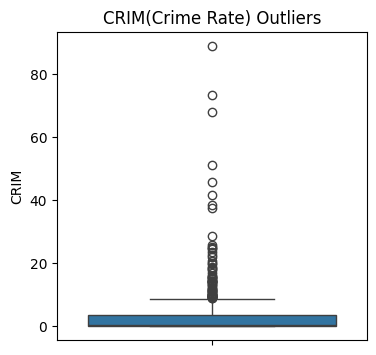

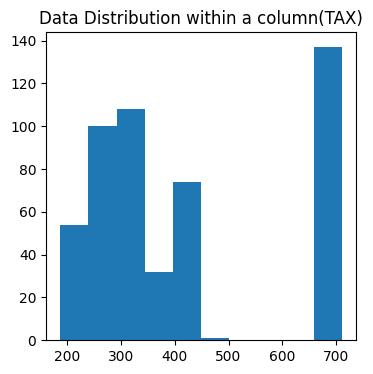

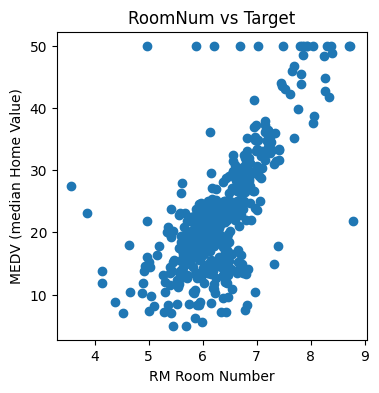

In [ ]:
# visualising the column value numerical distribution
plt.figure(figsize=(4,4))
sns.boxplot(y=df['CRIM'])
plt.title('CRIM(Crime Rate) Outliers')
plt.show()
plt.figure(figsize=(4,4))
plt.hist(df['TAX'])
plt.title('Data Distribution within a column(TAX)')
plt.show()
plt.figure(figsize=(4,4))
plt.scatter(df['RM'],df['MEDV'])
plt.title('RoomNum vs Target')
plt.xlabel('RM Room Number')
plt.ylabel('MEDV (median Home Value)')
plt.show()

In [ ]:
#Handling Missing values
df['CRIM']=df['CRIM'].fillna(df['CRIM'].median())
df['ZN']=df['ZN'].fillna(df['ZN'].median())
df['INDUS']=df['INDUS'].fillna(df['INDUS'].median())
df['CHAS']=df['CHAS'].fillna(df['CHAS'].median())
df['AGE']=df['AGE'].fillna(df['AGE'].median())
df['LSTAT']=df['LSTAT'].fillna(df['LSTAT'].median())
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
X=df.drop('MEDV', axis=1)
Y=df[['MEDV']]

In [ ]:
#Splitting data into trainset and test set
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.3,random_state=42)

In [ ]:
#Normalisation
sc=StandardScaler()
xtrain_scaled=sc.fit_transform(xtrain)
xtest_scaled=sc.transform(xtest)

In [ ]:
print(xtest.head(5))


        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
173  0.09178   0.0   9.69   0.0  0.510  6.416  76.8  2.6463    5  296   
274  0.05644  40.0   6.41   1.0  0.447  6.758  32.9  4.0776    4  254   
491  0.10574   0.0  27.74   0.0  0.609  5.983  98.8  1.8681    4  711   
72   0.09164   0.0  10.81   0.0  0.413  6.065   7.8  5.2873    4  305   
452  5.09017   0.0  18.10   0.0  0.713  6.297  91.8  2.3682   24  666   

     PTRATIO       B  LSTAT  
173     16.6  395.50   9.04  
274     17.6  396.90   3.53  
491     20.1  390.11  18.07  
72      19.2  390.91   5.52  
452     20.2  385.09  17.27  


**Model Training**

In [ ]:
lr=LinearRegression()
lr.fit(xtrain_scaled,ytrain)
lr_pred=lr.predict(xtest_scaled)

**Evaluation**

In [ ]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, r2
print("Linear Regression:", evaluate(ytest, lr_pred))


Linear Regression: (21.78436075879116, 0.7076438632327412)


**prediction**

In [ ]:
xx=np.array([5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24,66,20.2,385.09,17.27],ndmin=2)
xx=pd.DataFrame(xx,columns=xtrain.columns)
xxscaled=sc.transform(xx)
# print(xxscaled)
xxpredict=lr.predict(xxscaled)
print(xxpredict)     #predicted data

[[22.71264218]]


In [ ]:
print("X_test row:")   #actual data
display(xtest.loc[72])

print("\nActual MEDV:")
print(ytest.loc[72])


X_test row:


,72
CRIM,0.09164
ZN,0.00000
INDUS,10.81000
CHAS,0.00000
NOX,0.41300
RM,6.06500
AGE,7.80000
DIS,5.28730
RAD,4.00000
TAX,305.00000



Actual MEDV:
MEDV    22.8
Name: 72, dtype: float64


**finetuning
 actually for Linear Regression it is not to be better finetuned where as for  ridge and lasso regression,it is better**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr = LinearRegression()

grid = GridSearchCV(lr, params, cv=5, scoring='r2')
grid.fit(xtrain_scaled, ytrain)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Params: {'fit_intercept': True, 'positive': False}
Best Score: 0.6772002871821762
